# Notebook 3: Other Views of Persistent Homology

## Persistence Landscapes, Images, Density, and Betti Curves

In Notebook 2 we learned how to read persistence diagrams. In this notebook we will study **alternative visual representations** of the same topological information, with emphasis on:

1. **Persistence landscapes**
2. **Persistence images**
3. **Persistence density**
4. **Betti curves**

The goal is to build intuition for:
- what each visualization means,
- which parameters control it,
- how changing parameters modifies the output,
- and how this helps infer the shape of data.

We will intentionally **not use persistence barcodes** in this notebook.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import gudhi as gd
import tadasets

from ripser import ripser
from persim import plot_diagrams, PersistenceImager

from gtda.diagrams import PersistenceLandscape, BettiCurve, Scaler, Filtering

warnings.filterwarnings("ignore")
np.random.seed(2026)

## 1. Intuition and Reference Links

Persistent homology tracks features by pairs $(b, d)$ (birth, death). Alternative views summarize the same information in different ways:

- **Landscape:** converts each interval to tent functions and stacks them
- **Image:** converts diagram points into a pixel grid
- **Density:** estimates concentration of diagram points in the birth-death plane
- **Betti curve:** counts how many features are alive at each filtration value

These interactive links are still useful for geometric intuition:

- Connected components: https://gjkoplik.github.io/pers-hom-examples/0d_pers_2d_data_widget.html
- 1-dimensional hole: https://gjkoplik.github.io/pers-hom-examples/1d_pers_2d_data_widget.html
- Combined intuition: https://www.geogebra.org/m/muwz8vgx

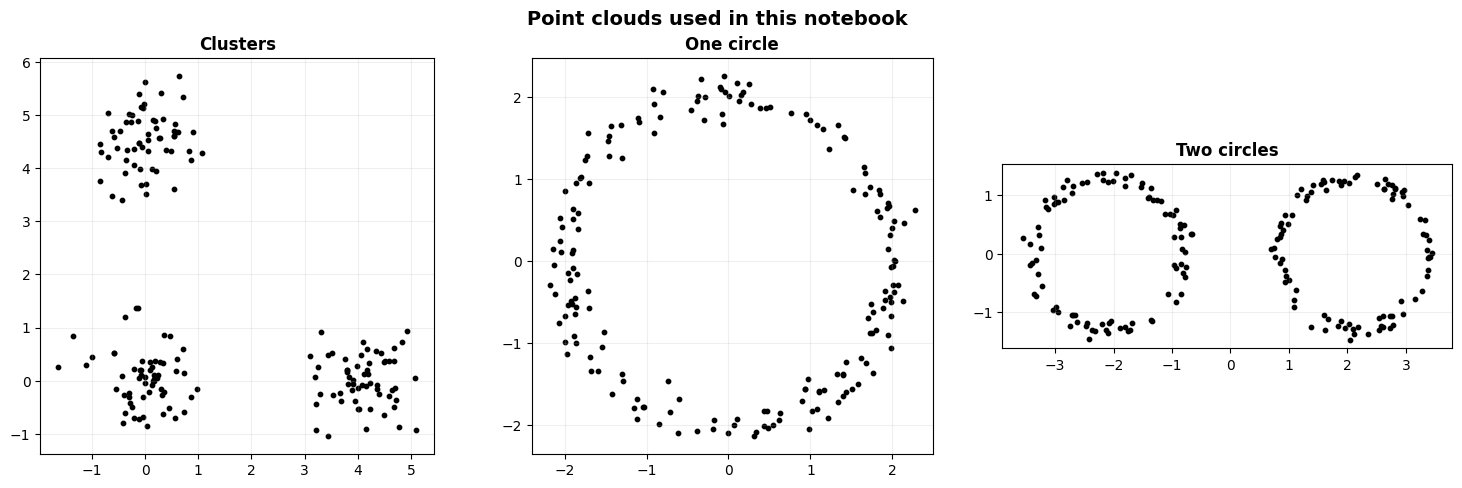

In [2]:
# Create three datasets with different topological structure
n = 180

# Noisy circle (one dominant loop)
X_circle = tadasets.dsphere(n=n, d=1, r=2.0, noise=0.12)

# Two noisy circles (two dominant loops)
X_two_a = tadasets.dsphere(n=n // 2, d=1, r=1.3, noise=0.08) + np.array([-2.1, 0.0])
X_two_b = tadasets.dsphere(n=n // 2, d=1, r=1.3, noise=0.08) + np.array([ 2.1, 0.0])
X_two = np.vstack([X_two_a, X_two_b])

# Clusters (many components, no strong H1)
X_clu1 = np.random.multivariate_normal([0, 0], [[0.25, 0], [0, 0.25]], size=60)
X_clu2 = np.random.multivariate_normal([4, 0], [[0.28, 0], [0, 0.20]], size=60)
X_clu3 = np.random.multivariate_normal([0, 4.5], [[0.22, 0], [0, 0.25]], size=60)
X_clusters = np.vstack([X_clu1, X_clu2, X_clu3])

datasets = {
    "Clusters": X_clusters,
    "One circle": X_circle,
    "Two circles": X_two,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
for ax, (name, X) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], s=10, c="black")
    ax.set_title(name, fontweight="bold")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)
plt.suptitle("Point clouds used in this notebook", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [3]:
# Compute persistence diagrams (Ripser) for each dataset
ripser_diagrams = {name: ripser(X, maxdim=1)["dgms"] for name, X in datasets.items()}

To compare the alternative visualizations, we first inspect the raw persistence diagrams (only as baseline). From these, all later representations are derived.

In the plots, focus on **H1**:
- clusters should have no dominant H1 point,
- one circle should have one dominant H1 point,
- two circles should have two dominant H1 points.

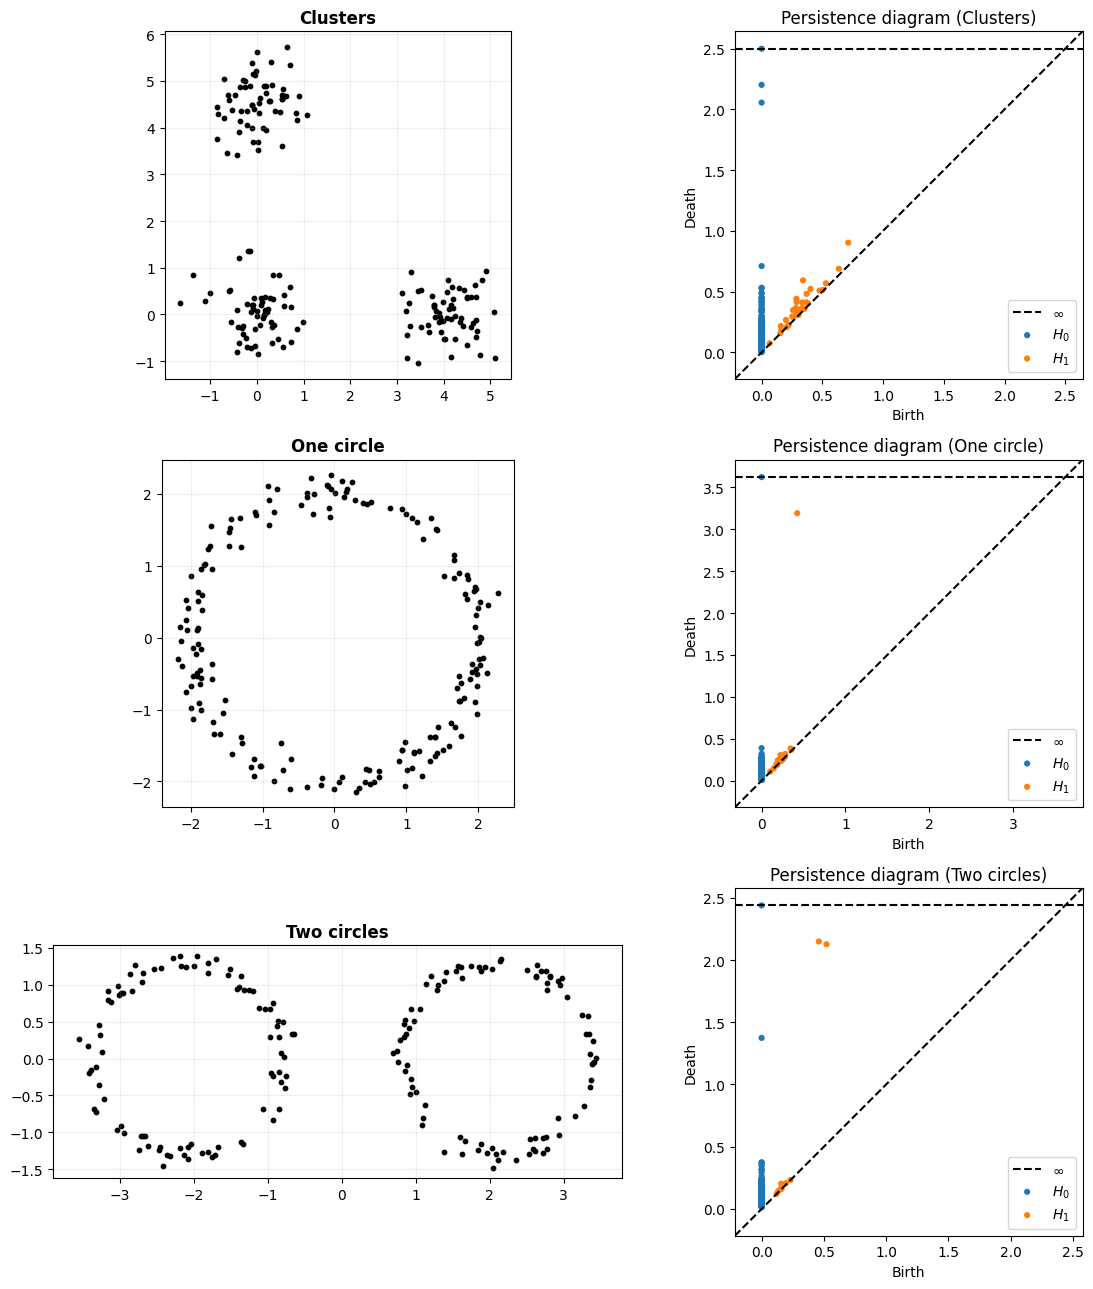

In [4]:
fig, axes = plt.subplots(3, 2, figsize=(12, 13))
for row, (name, X) in enumerate(datasets.items()):
    axes[row, 0].scatter(X[:, 0], X[:, 1], s=10, c="black")
    axes[row, 0].set_title(name, fontweight="bold")
    axes[row, 0].set_aspect("equal")
    axes[row, 0].grid(alpha=0.2)

    plot_diagrams(ripser_diagrams[name], ax=axes[row, 1], show=False,
                  title=f"Persistence diagram ({name})")

plt.tight_layout()
plt.show()

In [5]:
# Convert Ripser diagrams to Giotto-TDA format: [birth, death, homology_dimension]
def ripser_to_gtda(dgms):
    rows = []
    for q, dgm in enumerate(dgms):
        if len(dgm) == 0:
            continue
        finite = dgm[np.isfinite(dgm[:, 1])]
        for b, d in finite:
            rows.append([b, d, float(q)])
    if len(rows) == 0:
        return np.zeros((1, 3))
    return np.array(rows, dtype=float)

all_gtda = [ripser_to_gtda(ripser_diagrams[name]) for name in datasets.keys()]
max_pts = max(arr.shape[0] for arr in all_gtda)

# Pad with dummy zero-persistence points so we can stack into shape (n_samples, n_points, 3)
padded = []
for arr in all_gtda:
    pad = np.zeros((max_pts - arr.shape[0], 3), dtype=float)
    padded.append(np.vstack([arr, pad]))

gtda_diagrams = np.stack(padded)
print("Giotto-style diagram tensor shape:", gtda_diagrams.shape)

Giotto-style diagram tensor shape: (3, 207, 3)


In [6]:
# Optional filtering to suppress tiny-persistence noise in all later transforms
flt = Filtering(homology_dimensions=[0, 1], epsilon=0.02)
gtda_diagrams_filtered = flt.fit_transform(gtda_diagrams)

print("Using epsilon=0.02 to remove tiny intervals before vectorization.")

Using epsilon=0.02 to remove tiny intervals before vectorization.


In [7]:
# Normalize diagrams before representation transforms (helps comparability)
scaler = Scaler()
gtda_scaled = scaler.fit_transform(gtda_diagrams_filtered)

print("Scaler fitted and applied.")
print("Now all representations are computed from gtda_scaled.")

Scaler fitted and applied.
Now all representations are computed from gtda_scaled.


In [11]:
# 2. Persistence Landscapes
# Parameters to understand:
# - n_layers: how many landscape levels lambda_k we keep
# - n_bins: resolution of sampling on the filtration axis

landscape_low = PersistenceLandscape(n_layers=1, n_bins=80)
landscape_rich = PersistenceLandscape(n_layers=4, n_bins=300)

L_low = landscape_low.fit_transform(gtda_scaled)
L_rich = landscape_rich.fit_transform(gtda_scaled)

print("Landscape tensor shapes")
print("n_layers=1, n_bins=80  ->", L_low.shape)
print("n_layers=4, n_bins=300 ->", L_rich.shape)

Landscape tensor shapes
n_layers=1, n_bins=80  -> (3, 2, 80)
n_layers=4, n_bins=300 -> (3, 8, 300)


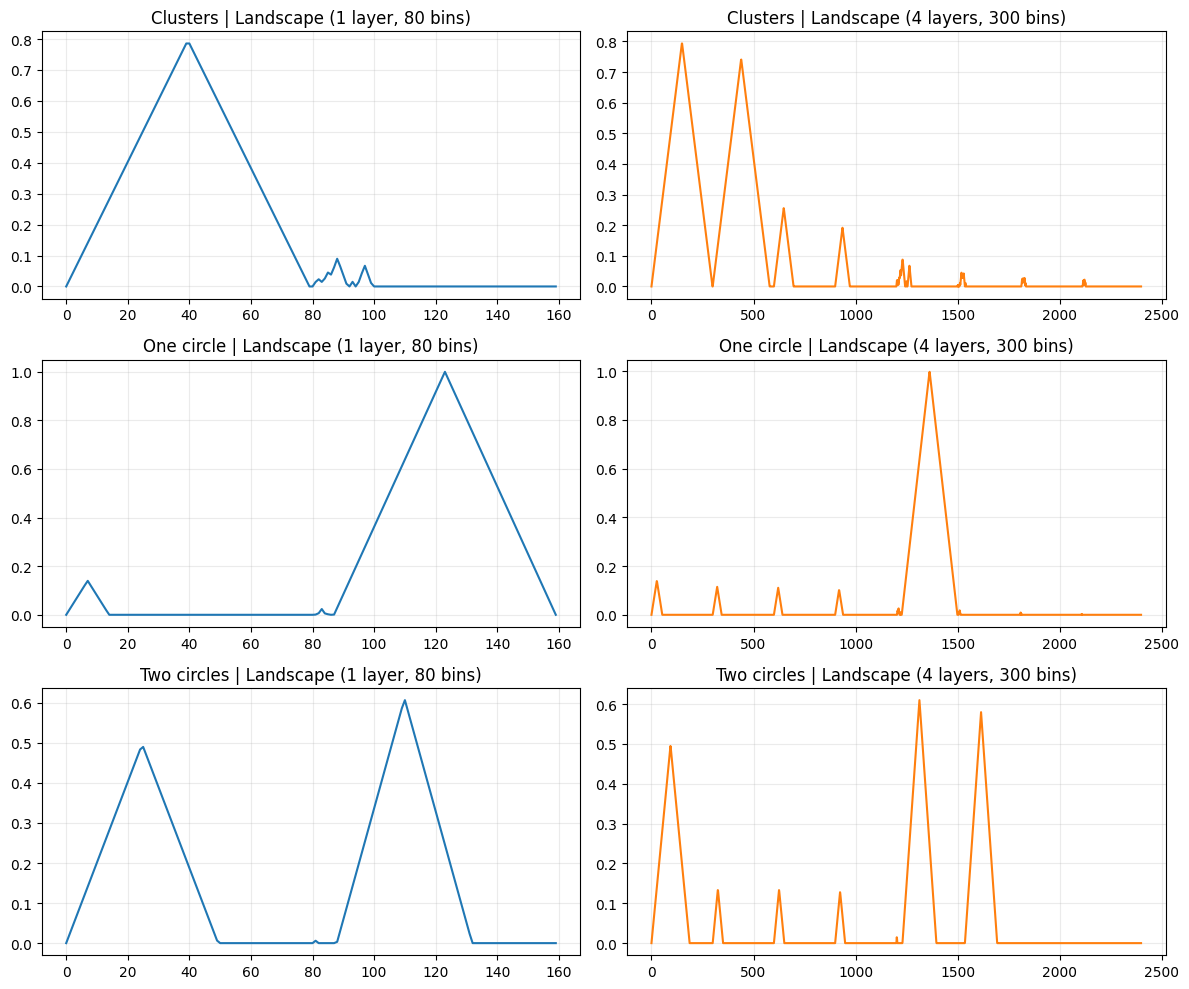

Interpretation:
- More layers capture secondary topological features
- More bins increase resolution but also sensitivity to noise


In [12]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10), sharex=False)
labels = list(datasets.keys())

for i, name in enumerate(labels):
    axes[i, 0].plot(L_low[i].ravel(), color="tab:blue")
    axes[i, 0].set_title(f"{name} | Landscape (1 layer, 80 bins)")
    axes[i, 0].grid(alpha=0.25)

    axes[i, 1].plot(L_rich[i].ravel(), color="tab:orange")
    axes[i, 1].set_title(f"{name} | Landscape (4 layers, 300 bins)")
    axes[i, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Interpretation:")
print("- More layers capture secondary topological features")
print("- More bins increase resolution but also sensitivity to noise")

## 3. Persistence Images

A persistence image turns a diagram into a 2D grid. Intuitively:

- each diagram point contributes a smooth bump,
- nearby bumps accumulate as intensity,
- output is a fixed-size numeric array usable in machine learning.

Key parameters:
- `pixel_size`: smaller values give higher resolution images,
- `birth_range` / `pers_range`: the visible window,
- weighting and smoothing (handled internally by the imager).

In [10]:
# Build persistence images from H1 diagrams (Ripser/Persim approach)
H1_diagrams = []
for name in datasets.keys():
    dgm1 = ripser_diagrams[name][1]
    finite = dgm1[np.isfinite(dgm1[:, 1])] if len(dgm1) else np.zeros((0, 2))
    H1_diagrams.append(finite)

pim_coarse = PersistenceImager(pixel_size=0.20)
pim_fine = PersistenceImager(pixel_size=0.06)

# fit on all H1 diagrams to set ranges consistently
pim_coarse.fit(H1_diagrams, skew=True)
pim_fine.fit(H1_diagrams, skew=True)

img_coarse = pim_coarse.transform(H1_diagrams, skew=True)
img_fine = pim_fine.transform(H1_diagrams, skew=True)

print("Persistence image resolutions")
print("coarse:", pim_coarse.resolution)
print("fine  :", pim_fine.resolution)

Persistence image resolutions
coarse: (4, 14)
fine  : (10, 47)


The side-by-side images below show the effect of `pixel_size`.

- Larger `pixel_size` (coarse grid): smoother but lower detail.
- Smaller `pixel_size` (fine grid): richer detail, but potentially more sensitivity to noise.

When your goal is robust classification, start coarse and then refine only if needed.

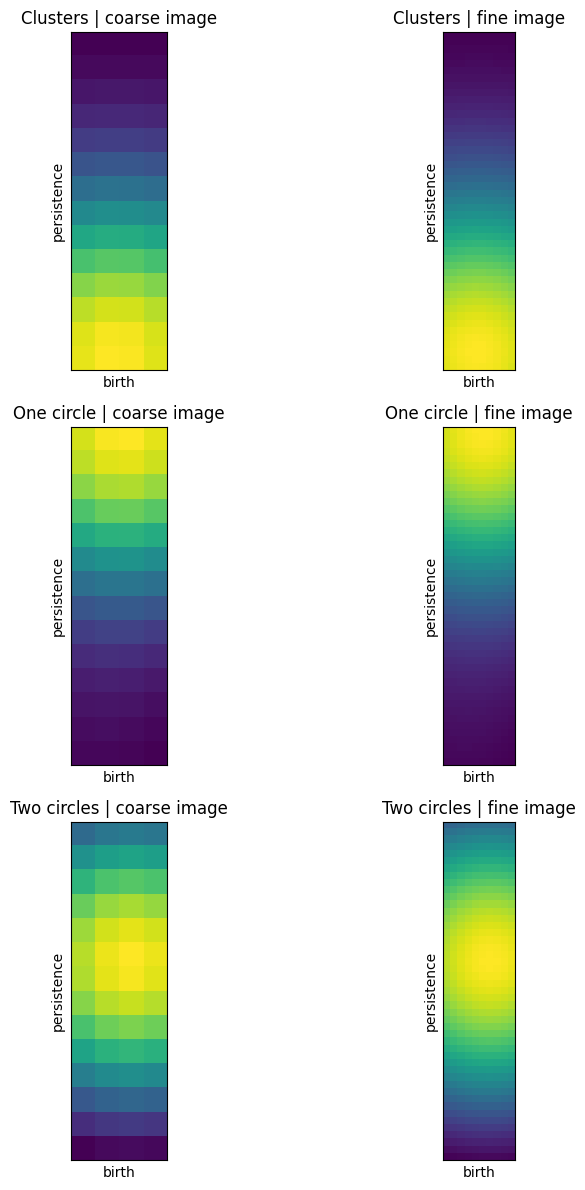

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(10, 12))
labels = list(datasets.keys())

for i, name in enumerate(labels):
    pim_coarse.plot_image(img_coarse[i], ax=axes[i, 0])
    axes[i, 0].set_title(f"{name} | coarse image")

    pim_fine.plot_image(img_fine[i], ax=axes[i, 1])
    axes[i, 1].set_title(f"{name} | fine image")

plt.tight_layout()
plt.show()

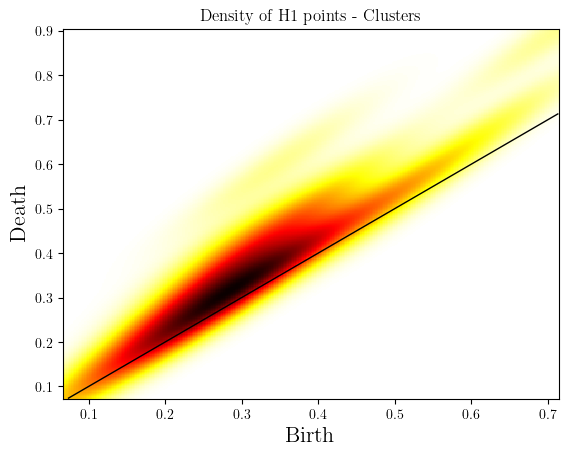

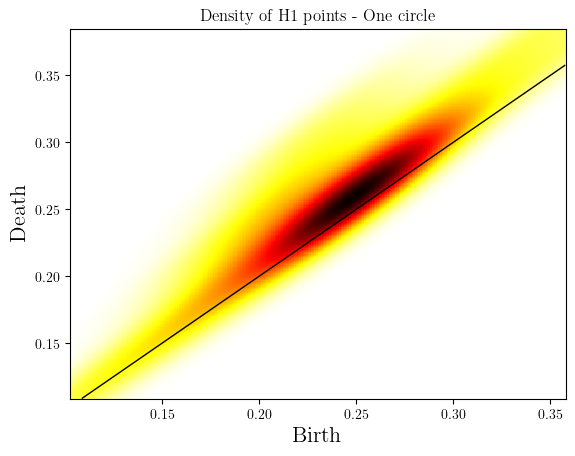

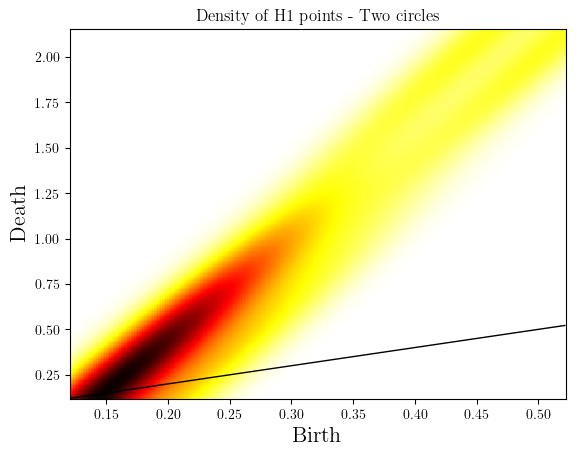

Interpretation:
High-density zones correspond to many features with similar birth/death.


In [21]:
# 4. Persistence Density (using Gudhi density plot on H1)
for name, X in datasets.items():
    st = gd.RipsComplex(points=X, max_edge_length=3.0).create_simplex_tree(max_dimension=2)
    diag = st.persistence(min_persistence=0.0)
    gd.plot_persistence_density(diag, legend=False, dimension=1)
    plt.title(f"Density of H1 points - {name}")
    plt.show()

print("Interpretation:")
print("High-density zones correspond to many features with similar birth/death.")

## 5. Betti Curves

The Betti curve for dimension $q$ gives
$$\beta_q(t) = \text{number of } q\text{-dimensional features alive at filtration value } t.$$

This converts a diagram into a function over filtration time.

Key parameter:
- `n_bins`: number of sampled filtration values. Larger values increase resolution.

Betti curve array shapes
coarse: (3, 2, 40)
fine  : (3, 2, 220)


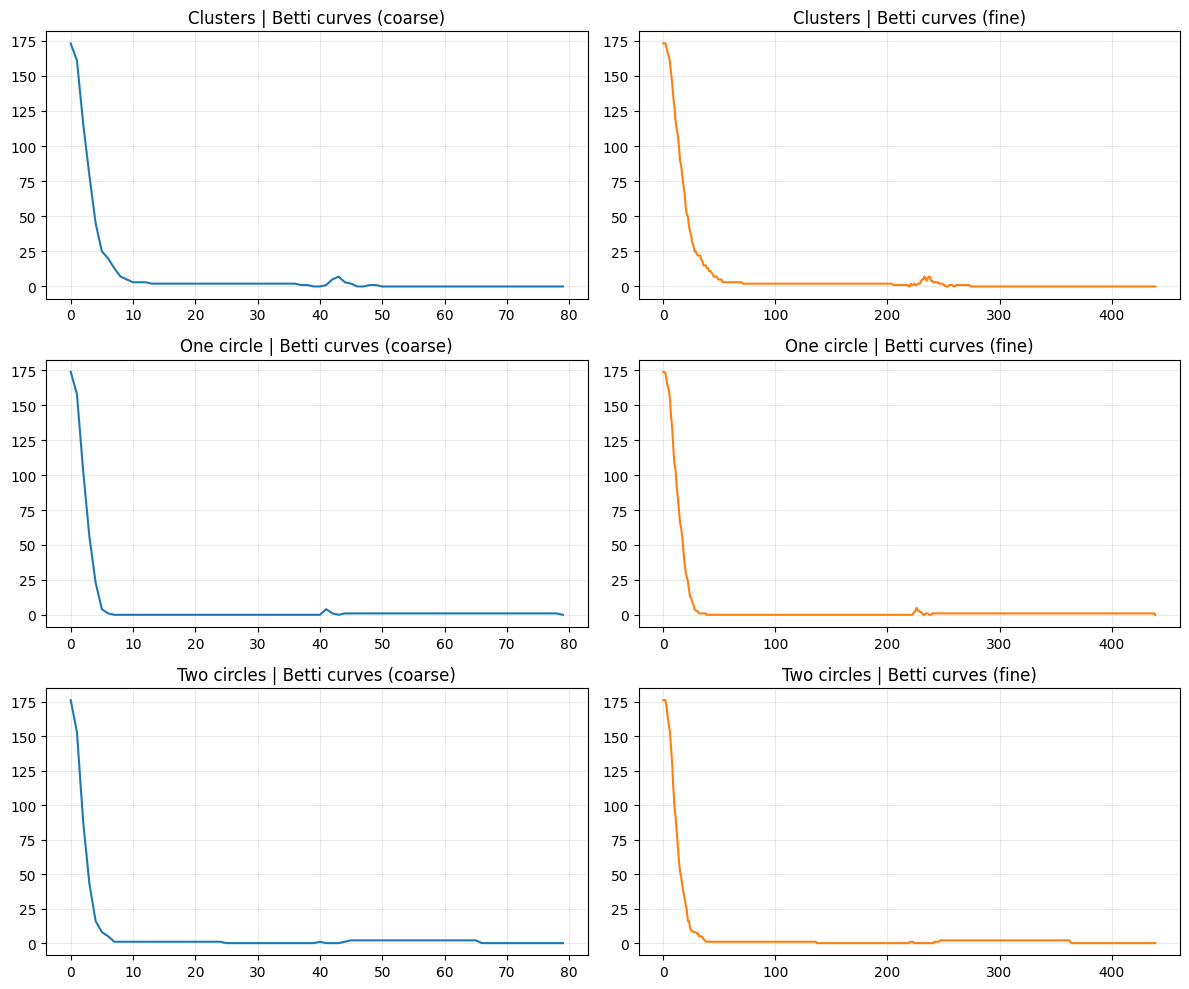

In [15]:
betti_coarse = BettiCurve(n_bins=40)
betti_fine = BettiCurve(n_bins=220)

B_coarse = betti_coarse.fit_transform(gtda_scaled)
B_fine = betti_fine.fit_transform(gtda_scaled)

print("Betti curve array shapes")
print("coarse:", B_coarse.shape)
print("fine  :", B_fine.shape)

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
labels = list(datasets.keys())

for i, name in enumerate(labels):
    axes[i, 0].plot(B_coarse[i].ravel(), color="tab:blue")
    axes[i, 0].set_title(f"{name} | Betti curves (coarse)")
    axes[i, 0].grid(alpha=0.25)

    axes[i, 1].plot(B_fine[i].ravel(), color="tab:orange")
    axes[i, 1].set_title(f"{name} | Betti curves (fine)")
    axes[i, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

## 6. Parameter Sensitivity: How Outputs Change

We now isolate one dataset (one circle) and vary parameters to observe output changes directly.

### Questions to answer while inspecting plots
1. Which parameters smooth the representation?
2. Which parameters increase detail but also amplify noise?
3. Which representation gives the clearest evidence of one loop in this dataset?

In [17]:
# Prepare circle-only data for parameter sweeps
circle_dgm = ripser_diagrams["One circle"]
circle_gtda = ripser_to_gtda(circle_dgm)

max_pts_one = max(30, circle_gtda.shape[0])
pad = np.zeros((max_pts_one - circle_gtda.shape[0], 3), dtype=float)
circle_tensor = np.expand_dims(np.vstack([circle_gtda, pad]), axis=0)

circle_tensor = Filtering(homology_dimensions=[0, 1], epsilon=0.02).fit_transform(circle_tensor)
circle_tensor = Scaler().fit_transform(circle_tensor)

circle_h1 = circle_dgm[1][np.isfinite(circle_dgm[1][:, 1])] if len(circle_dgm[1]) else np.zeros((0, 2))
print("Circle H1 points:", circle_h1.shape[0])

Circle H1 points: 22


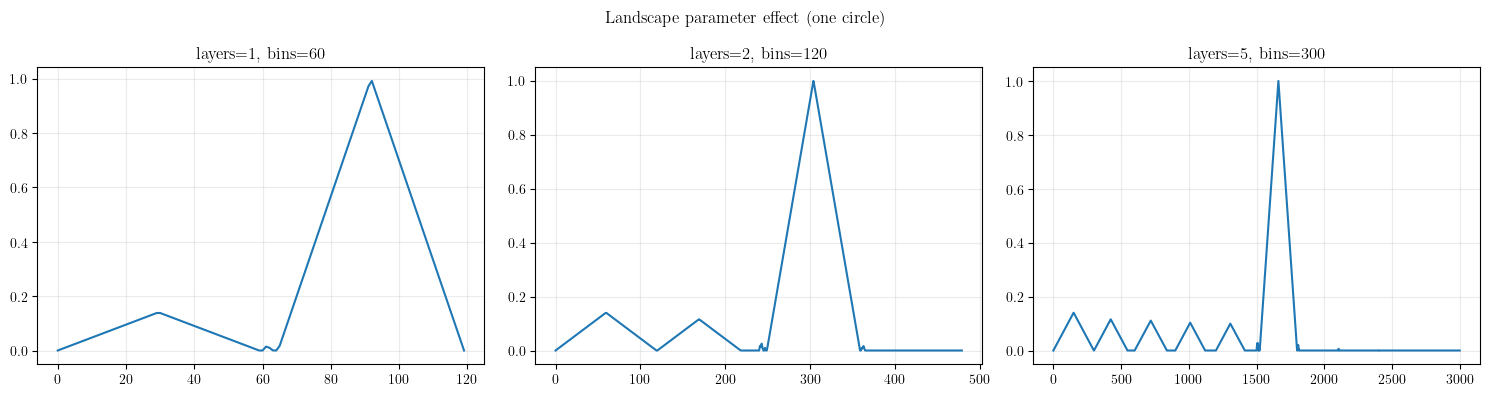

In [22]:
# Sweep 1: Landscape resolution and layers
configs_land = [(1, 60), (2, 120), (5, 300)]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (layers, bins) in zip(axes, configs_land):
    L = PersistenceLandscape(n_layers=layers, n_bins=bins).fit_transform(circle_tensor)
    ax.plot(L[0].ravel())
    ax.set_title(f"layers={layers}, bins={bins}")
    ax.grid(alpha=0.25)

plt.suptitle("Landscape parameter effect (one circle)", fontweight="bold")
plt.tight_layout()
plt.show()

In [19]:
# Sweep 2: Persistence image pixel size
p_small = PersistenceImager(pixel_size=0.05)
p_large = PersistenceImager(pixel_size=0.20)

p_small.fit([circle_h1], skew=True)
p_large.fit([circle_h1], skew=True)

img_small = p_small.transform([circle_h1], skew=True)[0]
img_large = p_large.transform([circle_h1], skew=True)[0]

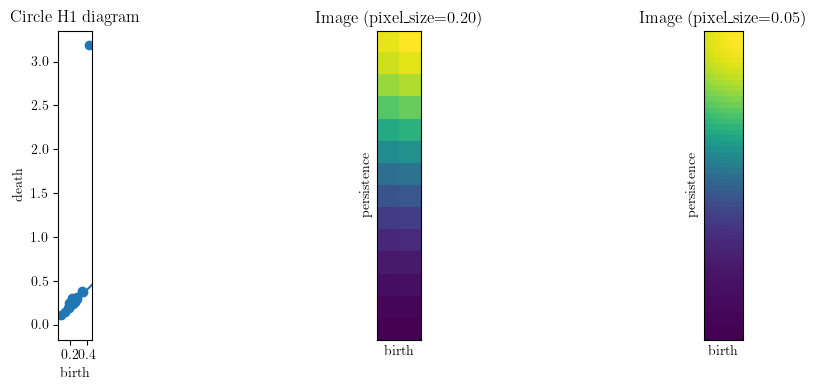

Smaller pixel_size gives more detailed but less smooth images.


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("Circle H1 diagram")
p_small.plot_diagram(circle_h1, skew=False, ax=axes[0])

axes[1].set_title("Image (pixel_size=0.20)")
p_large.plot_image(img_large, ax=axes[1])

axes[2].set_title("Image (pixel_size=0.05)")
p_small.plot_image(img_small, ax=axes[2])

plt.tight_layout()
plt.show()

print("Smaller pixel_size gives more detailed but less smooth images.")

## Summary and Interpretation Guide

### Quick interpretation map

- **Landscape**
  - Peaks correspond to persistent features
  - `n_layers` controls how many feature levels are kept
  - `n_bins` controls sampling resolution

- **Persistence image**
  - Bright regions indicate concentrated persistent features
  - `pixel_size` controls spatial resolution / smoothness trade-off

- **Persistence density**
  - Visual heat of point concentration in the birth-death plane
  - Useful to compare where features tend to appear/disappear

- **Betti curve**
  - Direct count of alive features along filtration time
  - Easy to read “how many components/loops are active” as scale changes

### Practical recommendation

For exploratory analysis:
1. Start with persistence diagrams (reference).
2. Use Betti curves for count-based intuition.
3. Use landscapes/images for machine-learning-friendly vectors.
4. Tune parameters from coarse to fine to avoid overfitting noise.

## Exercises

1. Generate a new point cloud with exactly one loop and stronger noise. Compare how landscapes and Betti curves react to noise.
2. For the same dataset, vary `pixel_size` in persistence images from 0.03 to 0.25. Which value best balances detail and stability?
3. Using the two-circles dataset, check if the four visualizations consistently suggest two significant H1 features.
4. Create a table with one row per representation and columns: key parameter, visual effect, interpretation risk.
5. Optional: try these representations on your own dataset and describe which one is easiest to interpret and why.

Further reading:
- Giotto-TDA representations: https://giotto-ai.github.io/gtda-docs/latest/modules/diagrams.html
- Persistence images (persim): https://persim.scikit-tda.org/en/latest/reference/stubs/persim.PersistenceImager.html
- Gudhi density plots: https://gudhi.inria.fr/python/latest/persistence_graphical_tools_ref.html